In [ ]:
!jupyter nbconvert --to markdown WebPresentation\ \(1\).ipynb

[NbConvertApp] Converting notebook WebPresentation (1).ipynb to markdown
[NbConvertApp] Writing 5652385 bytes to WebPresentation (1).md


# Exploring the Relationship between Legalized Abortion and Violent Crime Rate

By: Areeya Tipyasothi, Celine Shen, Shlok Sooch, Felipe Zuluaga, Ritvik Shah

## Introduction
#### Our Question:
We want to explore the relationship between legalized abortion and violent crime rates in the U.S. The idea is to see whether access to abortion services has any measurable impact on crime outcomes.

#### Why This Matters:
Understanding the relationship between legalized abortion and violent crime rates could shed light on how major policy decisions affect long-term social outcomes. If there is a strong link, it may help inform how we approach future legislation, reproductive rights, and crime prevention strategies. We also want to explore how other factors—like political leanings, alcohol consumption, and general fertility trends—also interact with abortion access and crime rates.

#### Data:
To answer our question, we analyzed several datasets:
- [Guttmacher Pregnancies, Births and Abortions in the US (1973-2020)](https://www.guttmacher.org/report/pregnancies-births-abortions-in-united-states-1973-2020)
- [FBI Crime Data Explorer for estimated crime and arrests data](http://cde.ucr.cjis.gov/LATEST/webapp/#/pages/home)
- [National Institute on Alcohol Abuse and Alcoholism Data Archive
](https://www.niaaa.nih.gov/research/data-archive-and-resources/niaaa-data-archive)
- [MIT Election lab data on presidential, senate and house races](https://electionlab.mit.edu/data)



#### Approach:
We’re focusing on correlation coefficients as our main unit of analysis—specifically, how abortion access measures relate to violent crime rates over time. Our methodology will draw from work like Donohue & Levitt’s cohort-based analysis, but with less emphasis on causal claims and more on observable trends across data.

#### Sources That Inform Our Work:
We’re building on foundational papers like:
- *Donohue & Levitt’s* work on abortion and crime in the U.S.
- *Sen’s Canadian analysis*, which adds fertility data into the equation
- Studies from Europe and Romania that test the same hypothesis under different legal systems and cultural norms
- *Critiques from Ted Joyce and others*, which challenge the strength of the abortion-crime link and suggest alternative explanations (like changing drug policy or demographics)

These studies gave us a good base to understand both the strengths and limitations of our approach and help shape the questions we ask of our own data.

## Data Import and Cleaning
We sourced our data from the Guttmacher Institute and the FBI Crime Data Explorer. The Guttmacher dataset includes annual state-level abortion statistics (rates, ratios, and counts) from 1988–2020, while the FBI data provides estimated violent crime figures. We joined these datasets by state and year, filtering the FBI data to only include relevant violent crime variables. Due to gaps in the abortion data between 1988–2005, our final dataset—labeled *abvi*—covers a limited but consistent time range and includes state, population, abortion, and violent crime data.

We addressed data quality issues by converting string-encoded numbers (with commas) into floats and filling missing numeric values with zeros, in line with source aggregation methods. Missing state values in the crime data, which corresponded to national totals, were replaced with “USA.”

While all data is publicly available, there were a few limitations we noted. FBI estimates rely on voluntary local reporting, leading to likely undercounts—especially post-2013 when the legal definition of rape changed.

The cleaned dataset looks like this:

`abvi.head()`

|   year | state   |      population |   total_violent |   homicide |   rape_legacy |   rape_revised |   robbery |   aggravated_assault |   abortionratiototal |   abortionratetotal |   abortionstotal |   abortions40plus |   abortions3539 |   abortions3034 |   abortions2529 |   abortions2024 |   abortionslt20 |   abortions1519 |   abortions1819 |   abortions1517 |   abortionslt15 |   abortionratio40plus |   abortionratio3539 |   abortionratio3034 |   abortionratio2529 |   abortionratio2024 |   abortionratiolt20 |   abortionratio1519 |   abortionratio1819 |   abortionratio1517 |   abortionratiolt15 |   abortionrate40plus |   abortionrate3539 |   abortionrate3034 |   abortionrate2529 |   abortionrate2024 |   abortionratelt20 |   abortionrate1519 |   abortionrate1819 |   abortionrate1517 |   abortionratelt15 |
|-------:|:--------|----------------:|----------------:|-----------:|--------------:|---------------:|----------:|---------------------:|---------------------:|--------------------:|-----------------:|------------------:|----------------:|----------------:|----------------:|----------------:|----------------:|----------------:|----------------:|----------------:|----------------:|----------------------:|--------------------:|--------------------:|--------------------:|--------------------:|--------------------:|--------------------:|--------------------:|--------------------:|--------------------:|---------------------:|-------------------:|-------------------:|-------------------:|-------------------:|-------------------:|-------------------:|-------------------:|-------------------:|-------------------:|
|   1988 | AK      | 513000          |            2682 |         29 |           296 |              0 |       374 |                 1983 |                240.4 |                19.8 |             2700 |                40 |             180 |             350 |             590 |             860 |             680 |             670 |             400 |             270 |              20 |                 323.4 |               194   |               142.7 |               165.4 |               272.7 |               653   |               645.6 |               569.4 |               805.7 |              1240.9 |                  2.3 |                6.9 |               11.3 |               25.2 |               43.9 |               36.8 |               35.9 |               57.8 |               23   |                4.3 |
|   1988 | AL      |      4.127e+06  |           23052 |        408 |          1228 |              0 |      4860 |                16556 |                330.9 |                21.3 |            20100 |               290 |            1120 |            2410 |            4320 |            6600 |            5360 |            5110 |            2830 |            2280 |             250 |                 709.4 |               376.2 |               245.1 |               245   |               342.2 |               505.6 |               495.6 |               457.2 |               553.6 |               866.5 |                  2.2 |                7.4 |               14.5 |               25.4 |               40.5 |               32.9 |               31.4 |               41.8 |               24   |                8.6 |
|   1988 | AR      |      2.422e+06  |           10237 |        211 |           780 |              0 |      2037 |                 7209 |                224.3 |                15   |             7860 |               140 |             420 |             810 |            1480 |            2480 |            2530 |            2440 |            1420 |            1020 |              90 |                 571   |               292.1 |               167.3 |               153.1 |               202.7 |               383.3 |               380.3 |               358.8 |               414.8 |               489.7 |                  1.8 |                4.9 |                8.9 |               15.9 |               27.9 |               28.2 |               27.2 |               39.4 |               19.1 |                5.4 |
|   1988 | AZ      |      3.466e+06  |           21147 |        294 |          1345 |              0 |      4750 |                14758 |                338.3 |                27   |            22200 |               270 |            1240 |            2840 |            5280 |            7390 |            5180 |            5050 |            3280 |            1770 |             130 |                 414.4 |               305.2 |               238.2 |               257.3 |               381.2 |               571.4 |               567.4 |               586.3 |               535.4 |               791.1 |                  2.4 |                9.3 |               18.7 |               33.1 |               53.8 |               40.4 |               39.4 |               61.1 |               23.7 |                5.5 |
|   1988 | CA      |      2.8168e+07 |          261912 |       2936 |         11780 |              0 |     86141 |               161055 |                584.2 |                44.9 |           311440 |              4650 |           19930 |           40510 |           70480 |           99680 |           76190 |           74360 |           45320 |           29050 |            1820 |                 600.8 |               443.5 |               350.4 |               423.4 |               715   |              1292.4 |              1285.2 |              1217.1 |              1408.1 |              1673.1 |                  4.9 |               17.3 |               30.3 |               52.3 |               87   |               76.8 |               75   |              109.5 |               50.3 |               10.5 |

5 rows x 42 columns

The shape of the cleaned dataset is 1020 rows by 42 columns with data on total violent crimes (alongside subcategories including homicide, rape (legacy/revised), robbery, and aggravated assault) as well as abortion data (broken down into raw numbers, rates, and ratios) for each state and year (1988-2020).

# Exploratory Data Analysis
To better understand our data, we examined correlations between abortion rates, violent crime subcategories, and maternal age at abortion. (Figures 1.1–1.2)

*Figure 1.1 — Correlation Matrix Heatmap between abortion and total violent crime and subcategories of total violent crime*

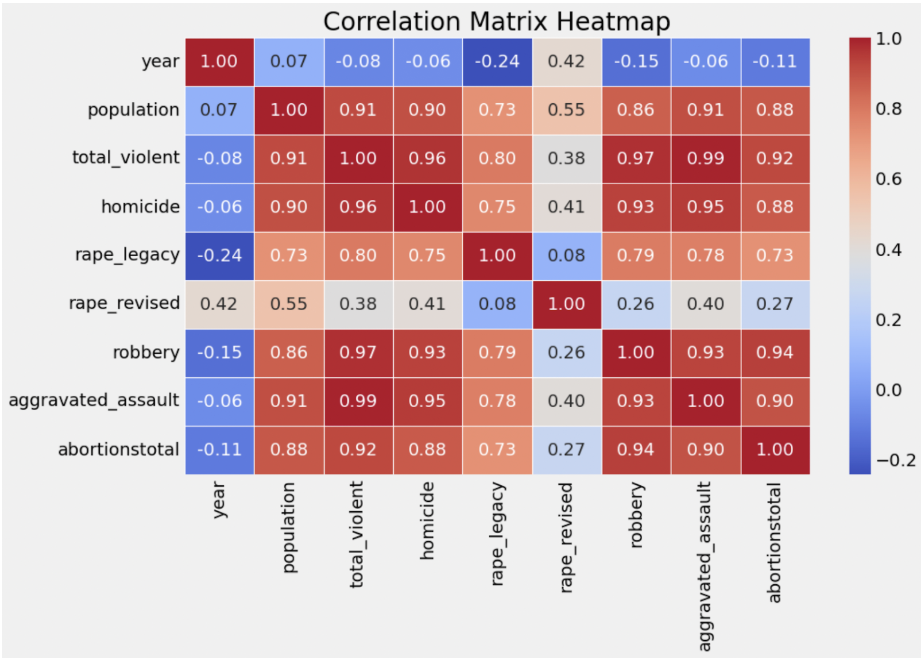

*Figure 1.2 — Correlation Matrix Heatmap between total violent crime and abortion broken down by age of mother*

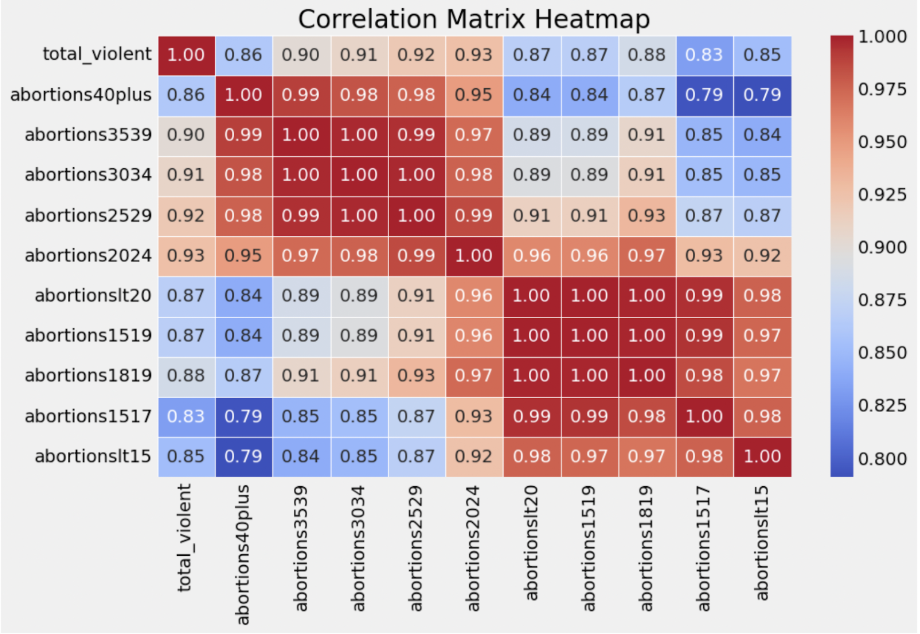

Total violent crime is strongly correlated with its subcategories (homicide, rape, robbery, and aggravated assault) since it’s their sum. The strong correlation with population suggests analyzing per capita crime rates may be more meaningful. Notably, violent crime total abortions also correlatescorrelate with total abortions violent crime, particularly among women aged 20–40.

We also analyzed trends and relationships through scatter plots, box plots, and line charts comparing abortion and violent crime rates over time and across states with varying abortion access (Figures 2.1–2.5)

*Figure 2.1 — Scatter Plot of Violent Crime Rate vs Total Abortion Rate and Violent Crime Rate vs Total Abortion Ratio*

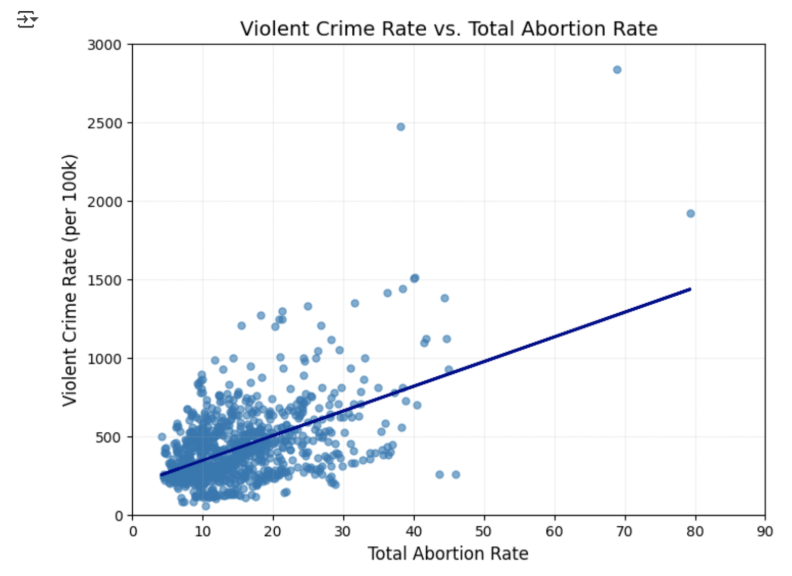

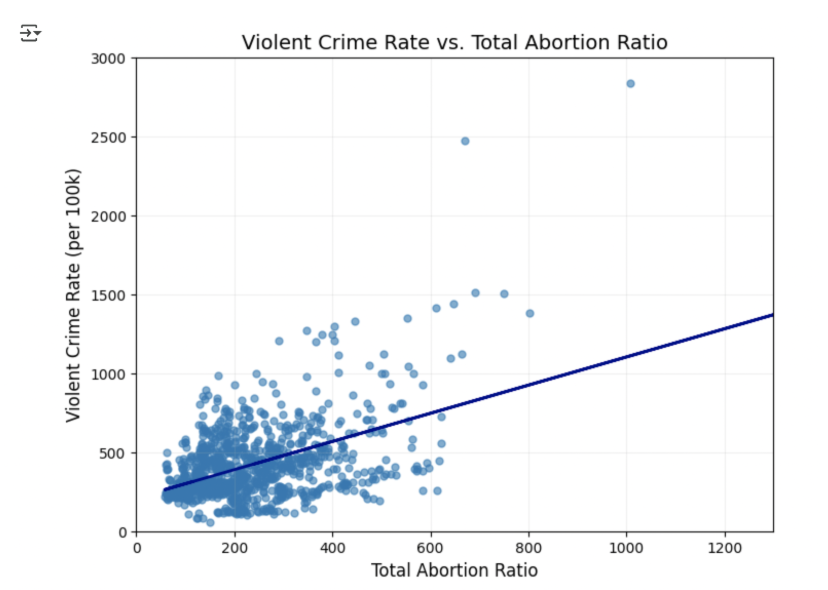

The scatter and time series plots explore correlations between abortion metrics and violent crime rates, with policy change annotations helping visualize pre- and post-legalization trends.

*Figure 2.2 — Box plots of crime rates in high vs low abortion access states over time*

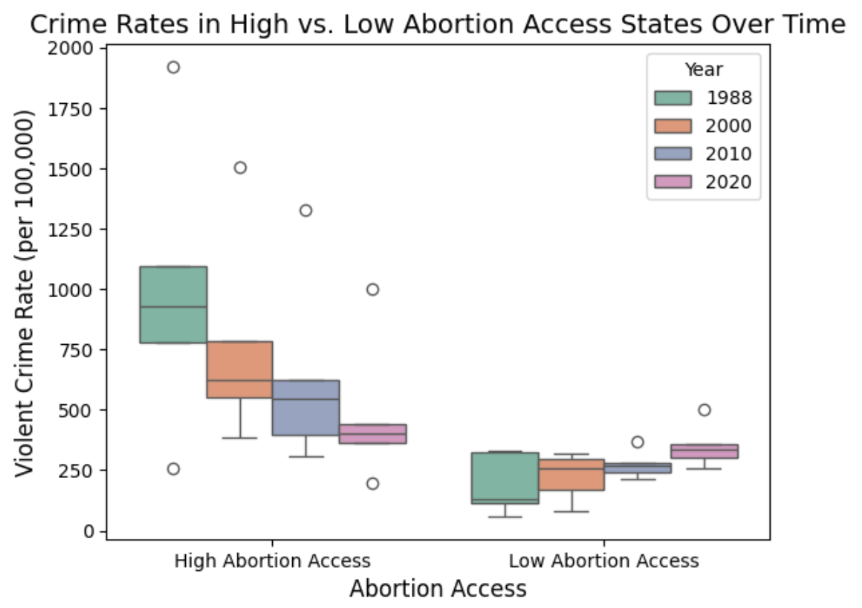

The boxplot shows states with high abortion access had consistently higher violent crime rates—driven by large urban centers—but the gap with low-access states narrowed as the latter's crime rates rose.

*Figure 2.3 — Line plot of total violent crimes and total abortions over time*

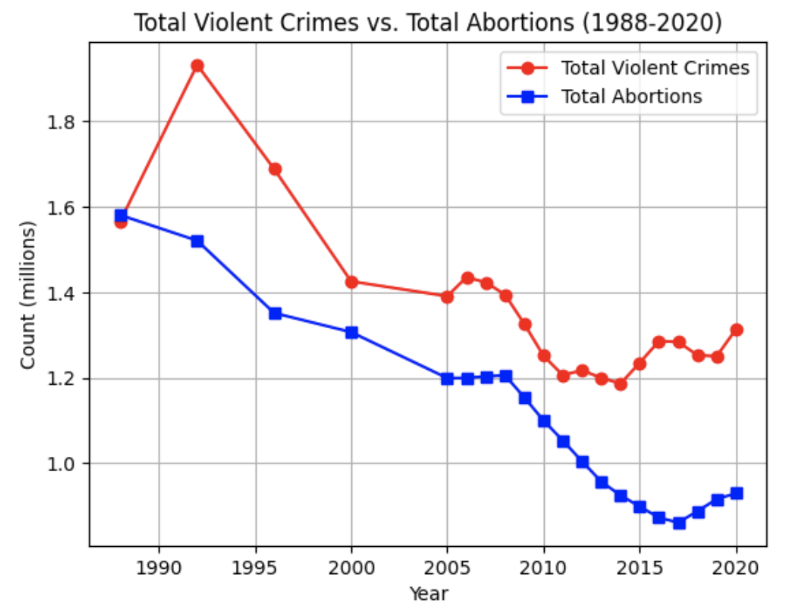

The line plot reveals violent crime peaked in 1992 and declined steadily, while abortions decreased more gradually, bottoming out in 2017.

*Figure 2.4 — Abortion Rate Over Time*

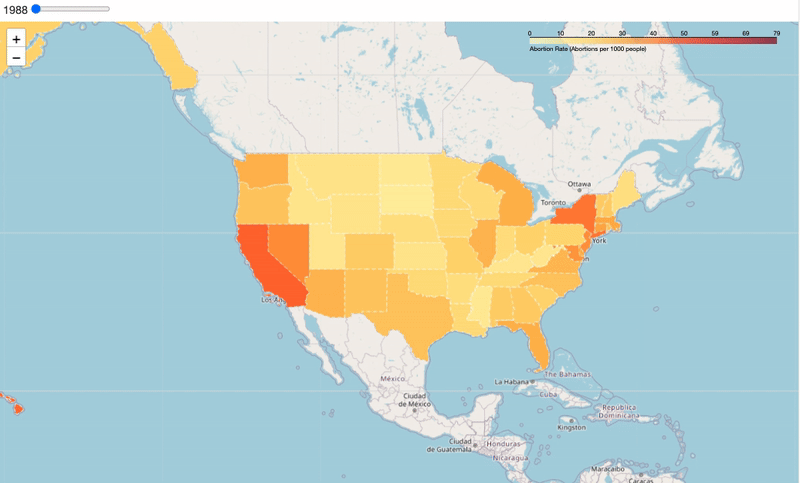

The abortion rate choropleth shows broad declines from 1988–2020, with the sharpest drops in coastal states like California and New York, while inland states remained consistently low.

*Figure 2.5 — Violent Crime Rate Over Time*

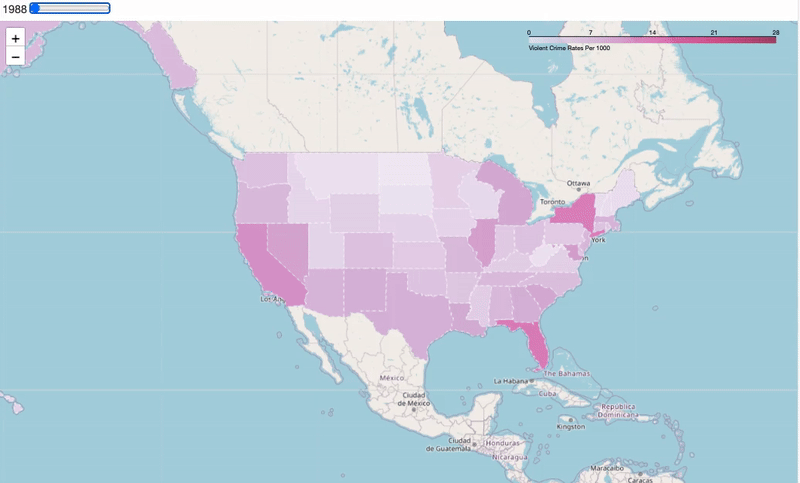

The violent crime choropleth shows a national decline after a 1992 peak, though states like New Mexico bucked the trend while others like California and New York showed steep drops.

# Modeling

#### Feature Engineering

We created several features to improve the predictive power of our model:
- **Lagged Abortion Rates:** Used abortion rates from earlier years as predictors for future violent crime, based on the theory that the effects of abortion access manifest over time.
- **Conservative Index:** Based on the assumption that more conservative states tend to have stricter abortion laws and reduced access. We calculated this index using presidential, senate, and house election data, dividing Republican votes by total votes. The resulting score ranges from 0 (more Democratic) to 100 (more Republican), serving as a proxy for abortion access and broader sociopolitical context.

#### Model Development
We split the dataset to test predictive accuracy with a time lag—for example, using 1988 abortion data to predict violent crime in 2006 (an 18-year gap). We used linear regression, a method well-suited for predicting continuous outcomes like violent crime rates based on multiple inputs. This approach allowed us to assess the contribution of each feature and visualize model performance.

We developed and compared two models:
- **Naive Model:** A basic regression model using only abortion rate data to predict violent crime rates.
- **Advanced Model:** A more complex model incorporating additional features such as drinking rates, environmental factors, and political conservatism.

We trained models on data from 1970–1995 and evaluated them on 1996–2010 to assess long-term predictive accuracy. This approach helped us understand the relative impact of abortion-related and contextual factors on violent crime over time.

#### Naive Model
```
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(abvi_final[X_cols], abvi_final[y_cols])

lr = LinearRegression()
lr.fit(X_train, y_train)

pred = lr.predict(X_test)
```

#### Naive Model Performance Evaluation
Some performance metrics for our model include:
- R²: About 50% of the variation in violent crime rates is explained by the model—moderate but leaves significant variance unexplained.
- RMSE: Predictions deviate by ~1 point on average, which is high given the violent crime rate ranges from 0 to 7.
- MAE: Average error is ~0.8, also relatively high considering the scale of the target variable.

```
lr.score(X_test,y_test) # R^2
```
0.48761622309225694
```
root_mean_squared_error(y_test,pred) # RMSE
```
1.1632535050354214
```
mean_absolute_error(y_test,pred) # MAE
```
0.7752124919815674

The most influential feature was the average conservatism index, which showed a positive correlation with violent crime 18 years later, suggesting that more conservative (and likely lower-access) states had higher future crime rates. However, abortion rates for women under 20 showed mixed results: rates for those under 15 were negatively correlated with future crime, while rates for ages 15–19 were positively correlated. These conflicting factors limit our ability to draw strong conclusions about abortion access and future crime. Future analysis could include adjusting the time lag (e.g., testing 16–20 years) and exploring whether prediction accuracy varies across states.

| Feature                   | Coefficient |
|---------------------------|-------------|
| avg_conservatism_index    | 1.749106    |
| abortionratelt20          | -1.697751   |
| abortionrate1519          | 1.362681    |
| violent_crime_rate_x      | 0.480454    |
| abortionratelt15          | 0.312344    |
| abortionrate40plus        | 0.229696    |
| abortionrate1517          | 0.218421    |
| abortionrate3539          | -0.194925   |
| abortionrate1819          | 0.164687    |
| abortionrate3034          | 0.106581    |
| abortionrate2024          | -0.073400   |
| abortionrate2529          | 0.019274    |

#### Advanced Model

```
df_model = df[features + [target]].dropna()

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
```

#### Advanced Model Performance Evaluation

Some performance metrics for our model include:
- R²: About 21% of the variation in violent crime rates is explained by the model
- RMSE: Predictions deviate by 1.35 point on average, which is high given the violent crime rate ranges from 0 to 7.

```
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
```
1.3563505463896657
```
r2 = r2_score(y_test, y_pred)
```
0.20869508493317712

The most influential features were abortion rates for women under 20, particularly those aged 15–19, which showed mixed results and limited our ability to draw clear conclusions about the relationship between abortion access and future crime. In contrast, wine consumption per capita consistently showed a negative correlation with crime, suggesting a potential protective effect or a proxy for broader socioeconomic factors, such as income or education.

| Feature              | Coefficient |
|----------------------|-------------|
| abortionratelt20     | -2.887136   |
| abortionrate1519     | 2.266997    |
| wine_percap_gal      | -1.306195   |
| spirits_18yr         | 1.136051    |
| avg_conservatism_index | 1.129060  |
| beer_percap_gal      | 1.120064    |
| spirits_percap_gal   | -0.728276   |
| abortionratelt15     | -0.538546   |
| violent_crime_rate_x | 0.516397    |
| wine_18yr            | -0.515930   |
| abortionrate3539     | -0.367391   |
| abortionrate1517     | 0.362654    |
| abortionrate1819     | 0.309777    |
| abortionrate3034     | 0.208379    |
| abortionrate40plus   | 0.175502    |
| beer_18yr            | 0.114467    |
| abortionrate2024     | -0.082081   |
| abortionrate2529     | 0.007437    |

This model also predicts violent crime rates 18 years into the future but uses per capita ethanol consumption from beer, wine, and hard liquor (1970s onward) as predictors. With an R² of ~0.2 and an RMSE of 1.3, it performed significantly worse than the abortion-based model. Feature coefficients revealed mixed effects: beer had a positive impact before the 18-year lag but a negative one after; wine was consistently negative; and hard liquor showed a slight positive effect. These results suggest that while alcohol consumption may relate to crime trends, adding more variables did not improve predictive accuracy and introduced interpretive complexity.

# Conclusion

Our analysis sought to explore whether legalized abortion has a measurable relationship with violent crime rates in the U.S., using data-driven modeling to observe long-term trends. The Naive Model, which used abortion rates alone to predict violent crime 18 years later, performed moderately well (R² ≈ 0.5) and suggested a consistent correlation and supporting the idea that abortion access could be a meaningful predictor of future crime outcomes, though not necessarily a causal factor.

In contrast, the Advanced Model incorporated alcohol consumption and other control variables, but performed worse (R² ≈ 0.2), showing that adding complexity did not enhance predictive power and may have introduced noise and ambiguity. The varied effects of different alcohol types—like the changing impact of beer before and after the 18-year lag—highlight how multiple social factors can interact in ways that are difficult to disentangle.

This outcome reinforces several key insights:
- Observable patterns suggest that abortion access may influence long-term crime rates, aligning with previous work like Donohue & Levitt.
- However, the inconsistency of results when adding more variables echoes critiques from researchers like Ted Joyce, emphasizing the need for caution in interpreting observational data.
- Finally, the reduced clarity in the Advanced Model illustrates a broader methodological lesson in that more variables don't always lead to better models or clearer conclusions.


Overall, our findings support the value of exploring large-scale policy impacts through cohort-based modeling, but they also underscore the limits of correlation-driven approaches. Future work could incorporate more rigorous causal inference methods or explore the interaction of abortion access with other factors like fertility rates, political shifts, and environmental stressors to better understand how these forces shape crime over time.
